In [3]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
     

cpu


In [4]:
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print(x_train.shape, x_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(25000, 200) (25000, 200)


In [7]:
x_train = torch.tensor(x_train, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.long)

x_test = torch.tensor(x_test, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
     

C:\Users\susha\AppData\Local\Temp\ipykernel_28056\1205409284.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train = torch.tensor(x_train, dtype=torch.long)
C:\Users\susha\AppData\Local\Temp\ipykernel_28056\1205409284.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
C:\Users\susha\AppData\Local\Temp\ipykernel_28056\1205409284.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test, dtype=torch.long)
C:\Users\susha\AppData\Local\Temp\ipykernel_28056\1205409

In [8]:
class TextModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, model_type="RNN"):
        super(TextModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)

        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        elif model_type == "GRU":
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):

        x = self.embedding(x)

        output, _ = self.rnn(x)

        output = output[:, -1, :]

        return self.fc(output)

In [9]:
def train_model(model, epochs=5):

    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(epochs):

        total_loss = 0

        for x, y in train_loader:

            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            outputs = model(x)

            loss = criterion(outputs, y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        losses.append(avg_loss)

        print("Epoch", epoch+1, "Loss:", avg_loss)

    return losses

In [10]:
rnn_model = TextModel(vocab_size, 128, 128, "RNN")
lstm_model = TextModel(vocab_size, 128, 128, "LSTM")
gru_model = TextModel(vocab_size, 128, 128, "GRU")

loss_rnn = train_model(rnn_model)
loss_lstm = train_model(lstm_model)
loss_gru = train_model(gru_model)

Epoch 1 Loss: 0.6494493423520452
Epoch 2 Loss: 0.5734869894164297
Epoch 3 Loss: 0.5431175593982267
Epoch 4 Loss: 0.5018033889858314
Epoch 5 Loss: 0.5616259329459247
Epoch 1 Loss: 0.5902968079537687
Epoch 2 Loss: 0.48188692937269234
Epoch 3 Loss: 0.3874158572662822
Epoch 4 Loss: 0.3639972407723327
Epoch 5 Loss: 0.27384820370875357
Epoch 1 Loss: 0.581209304768716
Epoch 2 Loss: 0.3954662444722622
Epoch 3 Loss: 0.2556673681263424
Epoch 4 Loss: 0.18220751980305327
Epoch 5 Loss: 0.12675209703100154


In [11]:
def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in test_loader:

            x, y = x.to(device), y.to(device)

            outputs = model(x)

            _, predicted = torch.max(outputs, 1)

            total += y.size(0)

            correct += (predicted == y).sum().item()

    acc = 100 * correct / total

    print("Accuracy:", acc)

    return acc
     

acc_rnn = evaluate(rnn_model)
acc_lstm = evaluate(lstm_model)
acc_gru = evaluate(gru_model)

print("RNN:", acc_rnn)
print("LSTM:", acc_lstm)
print("GRU:", acc_gru)

Accuracy: 75.532
Accuracy: 85.676
Accuracy: 87.776
RNN: 75.532
LSTM: 85.676
GRU: 87.776


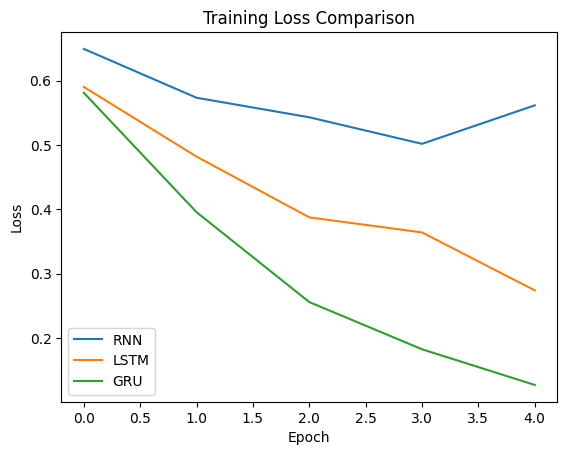

In [12]:

plt.plot(loss_rnn, label="RNN")
plt.plot(loss_lstm, label="LSTM")
plt.plot(loss_gru, label="GRU")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [13]:
def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x,y in test_loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            _, predicted = torch.max(outputs,1)

            total += y.size(0)

            correct += (predicted == y).sum().item()

    accuracy = 100 * correct / total

    return accuracy
     

acc_rnn = evaluate_model(rnn_model)
acc_lstm = evaluate_model(lstm_model)
acc_gru = evaluate_model(gru_model)

print("RNN Accuracy:", acc_rnn)
print("LSTM Accuracy:", acc_lstm)
print("GRU Accuracy:", acc_gru)

RNN Accuracy: 75.532
LSTM Accuracy: 85.676
GRU Accuracy: 87.776


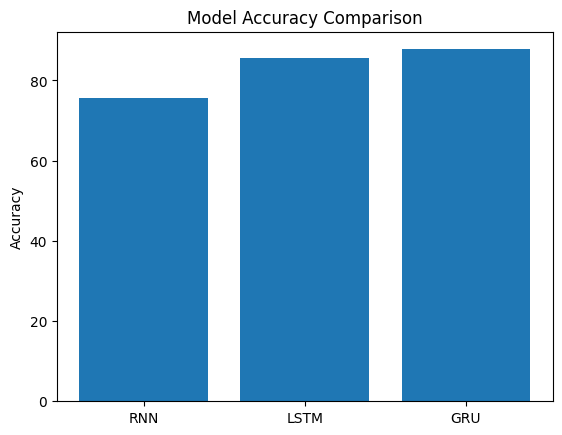

In [14]:
models = ["RNN","LSTM","GRU"]
accuracies = [acc_rnn, acc_lstm, acc_gru]

plt.bar(models,accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()
     
